# How well do jobs and skills pay for Data Analysts?

### Methodology

1. Evaluate median salary for top 6 data jobs
2. Find median salary per skill for Data Analysts
3. Visualize for highest paying skills and most demanded skills

In [2]:
# Importing Libraries

import ast
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset

# Loading data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [3]:
df_US = df[(df['job_country'] == 'United States')].dropna(subset=['salary_year_avg'])


In [4]:
job_titles = df_US['job_title_short'].value_counts().index[:6].tolist()

job_titles

['Data Scientist',
 'Data Analyst',
 'Data Engineer',
 'Senior Data Scientist',
 'Senior Data Engineer',
 'Senior Data Analyst']

In [5]:
df_US_top6 = df_US[df_US['job_title_short'].isin(job_titles)]

order_list = df_US_top6.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index

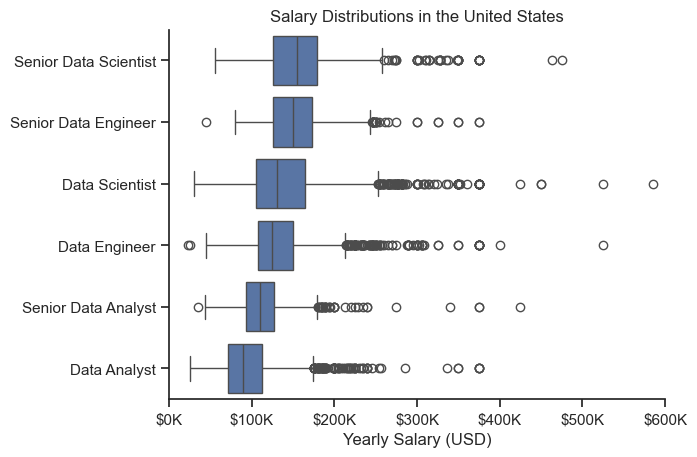

In [6]:
sns.set_theme(style = 'ticks')

sns.boxplot(data = df_US_top6, x = 'salary_year_avg', y = 'job_title_short', order = order_list)
sns.despine()

plt.title('Salary Distributions in the United States')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('')
plt.xlim(0,600_000)

ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))

plt.show()

### Investigate Median Salary Vs Skill for Data Analysts

In [7]:
df_DA_US = df[(df['job_country']=='United States') & (df['job_title_short']=='Data Analyst')].copy()

In [8]:
df_DA_US = df_DA_US.dropna(subset = ['salary_year_avg'])


In [9]:
df_DA_US = df_DA_US.explode('job_skills')

In [10]:
df_DA_US[['salary_year_avg','job_skills']].head()

,salary_year_avg,job_skills
109,89000.0,python
109,89000.0,r
109,89000.0,alteryx
109,89000.0,tableau
180,90250.0,excel


In [11]:
df_DA_top_pay = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by = 'median',ascending=False)

df_DA_top_pay =df_DA_top_pay.head(10)

df_DA_top_pay

,count,median
job_skills,,
dplyr,2,196250.0
bitbucket,3,189000.0
gitlab,3,186000.0
solidity,1,179000.0
hugging face,1,175000.0
couchbase,1,160515.0
ansible,1,159640.0
mxnet,2,149000.0
cassandra,6,148250.0


In [12]:
df_DA_skills = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by = 'count',ascending=False)

df_DA_skills =df_DA_skills.head(10).sort_values(by = 'median', ascending=False)

df_DA_skills

,count,median
job_skills,,
python,1431,97500.00
tableau,1364,92875.00
r,893,92500.00
sql server,286,92500.00
sql,2508,91000.00
sas,926,90000.00
power bi,838,90000.00
powerpoint,462,85000.00
excel,1808,84392.00


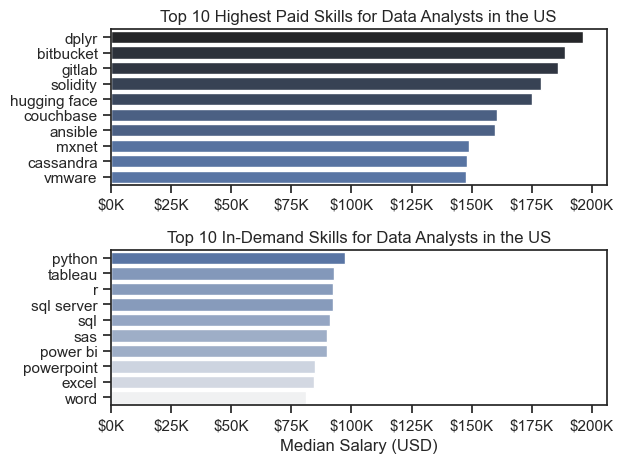

In [13]:
fig, ax = plt.subplots(2,1)

sns.set_theme(style='ticks')

# Top 10 Highest Paid Skills for Data Analysts in the US

sns.barplot(data = df_DA_top_pay, x = 'median', y = df_DA_top_pay.index, ax = ax[0], hue = 'median', palette = 'dark:b_r')

ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts in the US')
ax[0].set_xlabel('')
ax[0].set_ylabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
ax[0].legend().remove()


# Top 10 Most In-Demand Skills for Data Analysts in the US

sns.barplot(data = df_DA_skills, x = 'median', y = df_DA_skills.index, ax = ax[1], hue = 'median', palette = 'light:b')

ax[1].set_title('Top 10 In-Demand Skills for Data Analysts in the US')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].set_ylabel('')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
ax[1].set_xlim(ax[0].get_xlim()) # Set the same x-axis limits as the first plot
ax[1].legend().remove()

plt.tight_layout()
plt.show()

In [15]:
top_paid_skills   = set(df_DA_top_pay.index)
top_demand_skills = set(df_DA_skills.index)

overlap = top_paid_skills & top_demand_skills

print(f'Top 10 highest-paid skills:  {top_paid_skills}')
print(f'Top 10 most in-demand skills: {top_demand_skills}')
print(f'\nSkills appearing in both lists: {overlap}')
print(f'\nThese {len(overlap)} skill(s) are both well-paid AND commonly required.')

Top 10 highest-paid skills:  {'dplyr', 'cassandra', 'bitbucket', 'vmware', 'gitlab', 'mxnet', 'ansible', 'solidity', 'hugging face', 'couchbase'}
Top 10 most in-demand skills: {'sql', 'word', 'powerpoint', 'r', 'sql server', 'power bi', 'sas', 'excel', 'tableau', 'python'}

Skills appearing in both lists: set()

These 0 skill(s) are both well-paid AND commonly required.
